# Data Pre-Processing

## Imports

In [12]:
import os
import numpy as np
import pandas as pd
import cv2
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm

## Setup

In [13]:
DATA_DIR = "../data/raw/train_images/"
CSV_PATH = "../data/raw/train.csv"

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Load Data

In [14]:
df = pd.read_csv(CSV_PATH)
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['diagnosis'], random_state=42)
print(f"Train size: {len(train_df)}, Validation size: {len(val_df)}")

Train size: 2929, Validation size: 733


## Preprocessing Functions

In [15]:
def apply_clahe(img, **kwargs):
    img_lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(img_lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_eq = clahe.apply(l)
    img_lab_eq = cv2.merge((l_eq, a, b))
    return cv2.cvtColor(img_lab_eq, cv2.COLOR_LAB2RGB)

def circular_crop(img, **kwargs):
    h, w = img.shape[:2]
    mask = np.zeros((h, w), np.uint8)
    cv2.circle(mask, (w // 2, h // 2), min(w, h) // 2, 1, -1)
    img = cv2.bitwise_and(img, img, mask=mask)
    return img

## Albumentations Transformations

In [16]:
train_transforms = A.Compose([
    A.Lambda(image=apply_clahe),
    A.Lambda(image=circular_crop),
    A.Resize(256, 256),
    A.RandomCrop(224, 224),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.Rotate(limit=30, p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transforms = A.Compose([
    A.Lambda(image=apply_clahe),
    A.Lambda(image=circular_crop),
    A.Resize(224, 224),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

## Custom Dataset Class

In [17]:
class APTOSDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_id = self.dataframe.loc[idx, 'id_code']
        label = self.dataframe.loc[idx, 'diagnosis']
        img_path = os.path.join(self.img_dir, f"{img_id}.png")

        image = np.array(Image.open(img_path).convert('RGB'))

        if self.transform:
            image = self.transform(image=image)['image']

        return image, torch.tensor(label, dtype=torch.long)

## Weighted Sampling to Handle Class Imbalance

In [18]:
class_counts = train_df['diagnosis'].value_counts().sort_index()
class_weights = 1. / torch.tensor(class_counts.values, dtype=torch.float)
weights = [class_weights[label] for label in train_df['diagnosis']]
train_sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

## Create Datasets & Dataloaders

In [19]:
train_dataset = APTOSDataset(train_df, DATA_DIR, transform=train_transforms)
val_dataset = APTOSDataset(val_df, DATA_DIR, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=train_sampler, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

print(f"Batches per epoch: {len(train_loader)} (train), {len(val_loader)} (val)")

Batches per epoch: 92 (train), 23 (val)


## Visualize a Few Augmented Samples

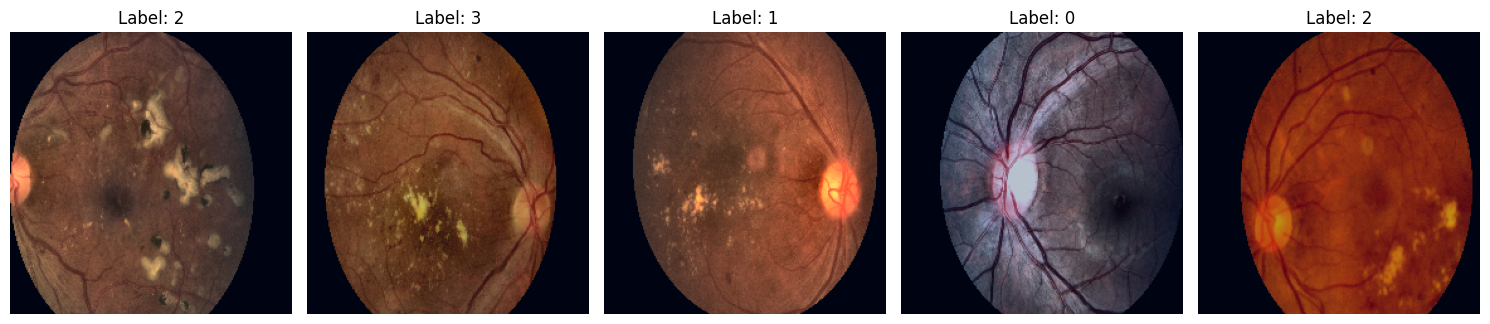

In [20]:
def visualize_augmentations(dataset, n=5):
    fig, axes = plt.subplots(1, n, figsize=(15, 5))
    for i in range(n):
        img, label = dataset[np.random.randint(len(dataset))]
        img = img.permute(1, 2, 0).cpu().numpy()
        img = np.clip(img * 0.229 + 0.485, 0, 1)
        axes[i].imshow(img)
        axes[i].set_title(f"Label: {label}")
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

visualize_augmentations(train_dataset)

In [ ]:
import pickle
import os

# Ensure directory exists
os.makedirs("../data/processed", exist_ok=True)

# Save loaders + class weights
data_objects = {
    "train_loader": train_loader,
    "val_loader": val_loader,
    "class_weights": class_weights
}

with open("../data/processed/loaders.pkl", "wb") as f:
    pickle.dump(data_objects, f)

print("Saved train/val DataLoaders and class weights to ../data/processed/loaders.pkl")

✅ Saved train/val DataLoaders and class weights to ../data/processed/loaders.pkl
